# Khám phá và Đánh giá Dữ liệu (EDA)

Notebook này được sử dụng để chuẩn bị dữ liệu (từ các bước 1, 2, 3 của pipeline) và sau đó đánh giá, phân tích dữ liệu trước khi đưa vào huấn luyện.

In [1]:
# ============================================================
# 1. Tai Ma nguon & Cai dat thu vien
# ============================================================ 
!git clone https://github.com/Shiba-dotcom/waste-detection2-Stage.git
!pip install -q ultralytics timm

Cloning into 'waste-detection2-Stage'...
remote: Enumerating objects: 322, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 322 (delta 20), reused 43 (delta 15), pack-reused 273 (from 2)
Receiving objects: 100% (322/322), 202.94 MiB | 39.98 MiB/s, done.
Resolving deltas: 100% (143/143), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distri

In [2]:
# ============================================================
# 2. Nap Du lieu Ngoai lai (TACO, TrashNet, RealWaste)
# ============================================================
import os, shutil

!mkdir -p /kaggle/working/waste-detection2-Stage/data/external/TrashNet
!mkdir -p /kaggle/working/waste-detection2-Stage/data/external/RealWaste
!mkdir -p /kaggle/working/waste-detection2-Stage/data/raw

datasets_to_copy = [
    {"src": "/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized",
     "dst": "/kaggle/working/waste-detection2-Stage/data/external/TrashNet"},
    {"src": "/kaggle/input/datasets/sohamchaudhari2004/taco-trash-detection-dataset/data",
     "dst": "/kaggle/working/waste-detection2-Stage/data/raw"},
    {"src": "/kaggle/input/datasets/joebeachcapital/realwaste/realwaste-main/RealWaste",
     "dst": "/kaggle/working/waste-detection2-Stage/data/external/RealWaste"}
]

for task in datasets_to_copy:
    if os.path.exists(task["src"]):
        os.makedirs(task["dst"], exist_ok=True)
        shutil.copytree(task["src"], task["dst"], dirs_exist_ok=True)
        print(f"Da tai: {os.path.basename(task['src'])}")
    else:
        print(f"Bo qua: {task['src']} (Khong tim thay tren Kaggle Dataset)")

Da tai: dataset-resized
Da tai: data
Da tai: RealWaste


In [3]:
# ============================================================
# 3. Tien xu ly Du lieu (Data Pipeline)
# ============================================================
%cd /kaggle/working/waste-detection2-Stage

print("--- 3.1 Don dep & Tao nhan YOLO ---")
!python src/data_prep/data_cleaning.py
!python src/Training_dataYolo.py
!python src/data_prep/split_dataset.py

print("--- 3.2 Chuan bi du lieu cho Stage 2 (Classifier) ---")
!python src/data_prep/crop_for_classification.py
!python src/data_prep/merge_external_datasets.py
!python src/data_prep/generate_background.py

print("Hoan tat chuan bi du lieu!")

/kaggle/working/waste-detection2-Stage
--- 3.1 Don dep & Tao nhan YOLO ---
  DATA CLEANING - TACO Dataset

[Load] annotations.json ...
  So anh goc         : 1500
  So annotations goc : 4784
  So categories      : 60

────────────────────────────────────────────────────────────
[Buoc 1] Kiem tra dong trung lap (Duplicates)
────────────────────────────────────────────────────────────
  Duplicate annotations: 0
  Duplicate image IDs: 0
  Duplicate file names: 0

────────────────────────────────────────────────────────────
[Buoc 2] Kiem tra gia tri thieu (Missing Values)
────────────────────────────────────────────────────────────
  Images: Tat ca truong bat buoc day du
  Annotations: Tat ca truong bat buoc day du
  Anh khong co annotation: 0

────────────────────────────────────────────────────────────
[Buoc 3] Kiem tra nhan khong hop le
────────────────────────────────────────────────────────────
  Annotations voi category_id khong hop le: 0
  Categories khong co trong mapping.csv: 1
  

In [9]:
# ============================================================
# 4. Đánh giá Dữ liệu Thành phần (TRƯỚC SÁP NHẬP)
# ============================================================
import os
import pandas as pd

# Mappings class từ các dataset ngoài về 5 class chính (như trong merge_external_datasets.py)
TRASHNET_MAPPING = {
    "cardboard": "Paper",      
    "glass":     "Glass",
    "metal":     "Metal",
    "paper":     "Paper",
    "plastic":   "Plastic",
    "trash":     "Other",
}

REALWASTE_MAPPING = {
    "Cardboard":           "Paper",
    "Food Organics":       "Other",
    "Glass":               "Glass",
    "Metal":               "Metal",
    "Miscellaneous Trash": "Other",
    "Paper":               "Paper",
    "Plastic":             "Plastic",
    "Textile Trash":       "Other",
    "Vegetation":          "Other",
}

OUR_CLASSES = ["Glass", "Metal", "Other", "Paper", "Plastic"]

def count_images(base_dir, mapping=None):
    """Đếm số lượng ảnh trong thư mục (có hỗ trợ mapping class)"""
    counts = {cls: 0 for cls in OUR_CLASSES}
    if not os.path.exists(base_dir):
        return counts
        
    for root, dirs, files in os.walk(base_dir):
        images = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        if len(images) > 0:
            folder_name = os.path.basename(root)
            # Áp dụng mapping nếu có, nếu không thì dùng tên folder gốc
            mapped_class = mapping.get(folder_name) if mapping else folder_name
            if mapped_class in OUR_CLASSES:
                counts[mapped_class] += len(images)
    return counts

print("================ THỐNG KÊ CÁC BỘ DỮ LIỆU THÀNH PHẦN ================")

# 1. TACO crops (từ crop_for_classification.py)
taco_dir = 'data/classification'
taco_counts = count_images(taco_dir)

# 2. TrashNet
trashnet_dir = 'data/external/TrashNet'
trashnet_counts = count_images(trashnet_dir, TRASHNET_MAPPING)

# 3. RealWaste
realwaste_dir = 'data/external/RealWaste'
realwaste_counts = count_images(realwaste_dir, REALWASTE_MAPPING)

# Tổng hợp DataFrame
stats = []
for cls in OUR_CLASSES:
    row = {
        'Phân lớp (Class)': cls,
        'TACO (Ảnh crop)': taco_counts[cls],
        'TrashNet': trashnet_counts[cls],
        'RealWaste': realwaste_counts[cls],
        'Tổng cộng (Các lớp rác)': taco_counts[cls] + trashnet_counts[cls] + realwaste_counts[cls]
    }
    stats.append(row)

df_components = pd.DataFrame(stats)
df_components.set_index('Phân lớp (Class)', inplace=True)

# Thêm dòng Tổng số lượng
df_components.loc['Tổng số lượng'] = df_components.sum()

print("\n--- BẢNG THÔNG SỐ TRƯỚC SÁP NHẬP ---")
print(df_components.to_markdown())


================ THỐNG KÊ CÁC BỘ DỮ LIỆU THÀNH PHẦN ================

--- BẢNG THÔNG SỐ TRƯỚC SÁP NHẬP ---
| Phân lớp (Class)   |   TACO (Ảnh crop) |   TrashNet |   RealWaste |   Tổng cộng (Các lớp rác) |
|:-------------------|------------------:|-----------:|------------:|--------------------------:|
| Glass              |               616 |        501 |         420 |                      1537 |
| Metal              |               794 |        410 |         790 |                      1994 |
| Other              |              1132 |        137 |        1660 |                      2929 |
| Paper              |               669 |        997 |         961 |                      2627 |
| Plastic            |              1230 |        482 |         921 |                      2633 |
| Tổng số lượng      |              4441 |       2527 |        4752 |                     11720 |


================ THỐNG KÊ DỮ LIỆU TẠI: data/classification_merged ================

--- BẢNG THỐNG KÊ CHI TIẾT ---
| Lớp        |   TEST |   TRAIN |   VAL |   Tổng |
|:-----------|-------:|--------:|------:|-------:|
| Background |    400 |    2500 |   400 |   3300 |
| Glass      |    185 |    1197 |   155 |   1537 |
| Metal      |    251 |    1486 |   257 |   1994 |
| Other      |    482 |    1974 |   473 |   2929 |
| Paper      |    361 |    1908 |   358 |   2627 |
| Plastic    |    484 |    1667 |   482 |   2633 |
| Tổng       |   2163 |   10732 |  2125 |  15020 |


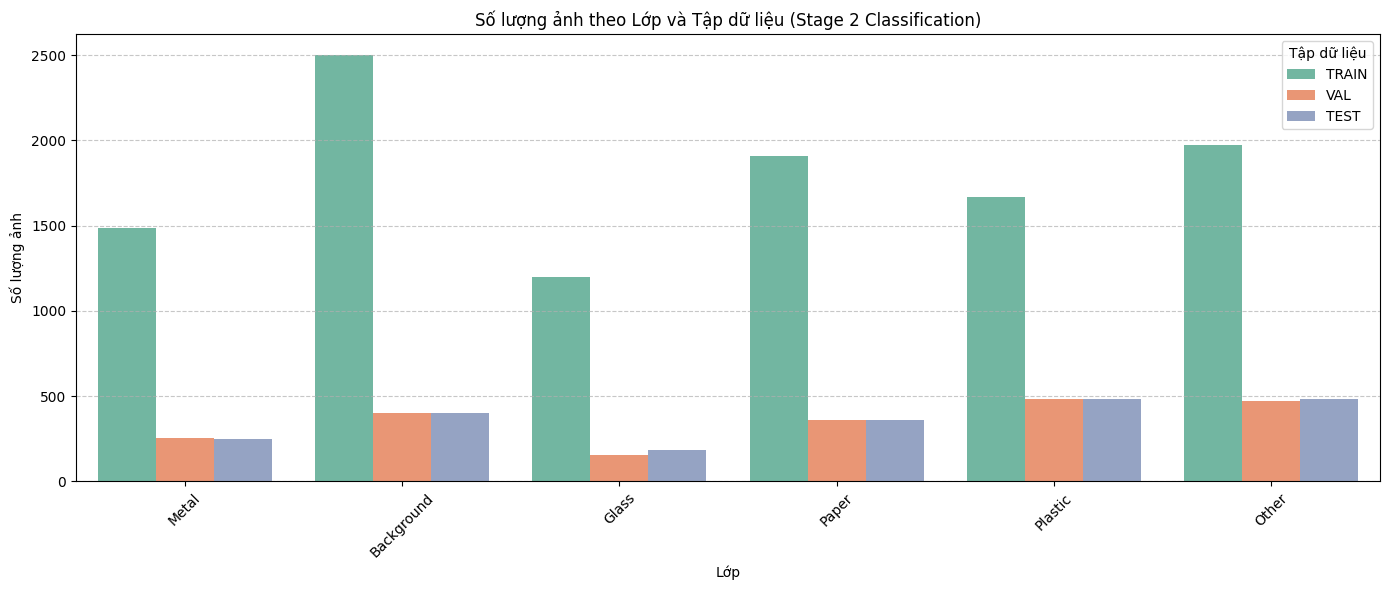

In [10]:
# ============================================================
# 5. Đánh giá và Phân tích Dữ liệu Stage 2 (EDA)
# ============================================================
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2

def analyze_split(split_dir):
    """Đếm số lượng ảnh từng class trong 1 tập (train/val/test)"""
    if not os.path.exists(split_dir):
        return {}
    
    counts = {}
    # Mỗi thư mục con là 1 class
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[class_name] = len(images)
    return counts

# Đường dẫn tới dataset CUỐI CÙNG sau khi qua toàn bộ pipeline 3.2
# bao gồm crop_for_classification, merge_external_datasets và generate_background
dataset_dir = 'data/classification_merged'
if not os.path.exists(dataset_dir):
    # Nếu không tìm thấy, thử đường dẫn trước khi merge
    dataset_dir = 'data/classification'

print(f"================ THỐNG KÊ DỮ LIỆU TẠI: {dataset_dir} ================")
if os.path.exists(dataset_dir):
    all_stats = []
    splits = ['train', 'val', 'test']
    
    for split in splits:
        split_path = os.path.join(dataset_dir, split)
        counts = analyze_split(split_path)
        for cls, count in counts.items():
            all_stats.append({'Tập dữ liệu': split.upper(), 'Lớp': cls, 'Số lượng': count})
            
    if len(all_stats) > 0:
        df = pd.DataFrame(all_stats)
        
        # 1. In ra bảng số lượng chi tiết
        print("\n--- BẢNG THỐNG KÊ CHI TIẾT ---")
        pivot_df = df.pivot(index='Lớp', columns='Tập dữ liệu', values='Số lượng').fillna(0).astype(int)
        # Tính tổng theo từng tập và lớp
        pivot_df.loc['Tổng'] = pivot_df.sum()
        pivot_df['Tổng'] = pivot_df.sum(axis=1)
        print(pivot_df.to_markdown())
        
        # 2. Vẽ biểu đồ
        plt.figure(figsize=(14, 6))
        sns.barplot(data=df, x='Lớp', y='Số lượng', hue='Tập dữ liệu', palette='Set2')
        plt.title('Số lượng ảnh theo Lớp và Tập dữ liệu (Stage 2 Classification)')
        plt.ylabel('Số lượng ảnh')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Không tìm thấy ảnh. Pipeline có thể chưa chạy xong hoặc chưa tạo đúng thư mục.")
else:
    print(f"Không tìm thấy thư mục '{dataset_dir}'. Vui lòng chạy cell số 3 trước.")
